ANDMESTIK DIABEET200


Andmestikus on 200 inimese tervisenäitajad (vanus, kehamassiindeks, vererõhk, seerumi kolesterool, s2 lipoproteiin, s3 lipoproteiin, HDL, triglütseriid, veresuhkur). Lisaks on andmestikus iga inimese diabeedi raskusaste vahemikus 0 - 400 (haiguse kulg). Eesmärk on seda väärtust ennustada.

Andmestikule on rakendatud lineaarset ja polünomiaalset regressiooni, otsustuspuud ning otsustusmetsa, ennustamaks pidevat muutujat (haiguse kulgu).

Treenitud mudelite headust on hinnatud R2 skooriga.

In [36]:
import pandas as pd
import numpy as np

diabeet_df = pd.read_csv(r".\diabeet200_csv.csv").drop(columns='Unnamed: 0')

diabeet_df

,haiguse kulg,vanus,kehamassiindeks,vererohk,seerumi kolesterool,s2 lipoproteiin,s3 lipoproteiin,HDL,triglütseriid,veresuhkur
0,336,-0.533604,0.861868,-0.207436,0.117998,1.130279,-0.484536,0.579523,0.613790,0.228000
1,328,-0.716321,1.556190,-0.612304,-0.440421,1.137331,-0.502183,0.029116,-0.147897,-0.079941
2,75,0.365642,-0.657873,-0.100782,-0.135047,0.960743,-0.299528,-0.033411,0.523049,-0.168043
3,52,-0.419618,0.152124,-0.330364,0.353281,1.077474,0.634835,-0.345687,-0.154659,-0.242600
4,86,0.542098,-0.507379,0.688486,0.201821,1.230003,-0.433897,0.511953,0.129212,0.266155
...,...,...,...,...,...,...,...,...,...,...
195,90,0.607586,0.188962,-0.021613,-0.726250,1.011543,-0.558174,0.112152,0.266377,-0.119677
196,257,0.085965,0.077377,0.320107,0.220639,1.232932,0.503295,-0.469909,0.090462,0.204355
197,170,-0.322837,0.667553,0.954757,0.677859,1.193552,-0.221840,0.619792,0.503167,0.366912
198,247,0.355699,-0.503436,0.057471,0.249401,1.059383,-0.132542,0.328499,0.468623,-0.471168


## Uurimuslik andmeanalüüs

In [37]:
diabeet_df.describe()

,haiguse kulg,vanus,kehamassiindeks,vererohk,seerumi kolesterool,s2 lipoproteiin,s3 lipoproteiin,HDL,triglütseriid,veresuhkur
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,190.115000,-0.021067,0.335251,0.037989,-0.025182,1.137751,-0.051244,0.002900,0.071715,0.053034
std,118.237993,0.392483,0.713059,0.512033,0.398692,0.078047,0.481345,0.450054,0.465711,0.488642
min,0.000000,-0.857959,-0.890463,-1.121878,-0.851758,0.917841,-0.968493,-0.921947,-1.043084,-1.160280
25%,83.750000,-0.310224,-0.224260,-0.321575,-0.348097,1.084480,-0.390918,-0.344340,-0.262296,-0.303331
50%,183.500000,-0.026638,0.320201,-0.002824,-0.015020,1.143154,-0.146870,0.004538,0.107494,0.065329
75%,289.500000,0.254507,0.820941,0.423086,0.274984,1.190688,0.215339,0.298695,0.390260,0.348228
max,398.000000,0.885364,1.797891,1.326115,1.309698,1.316642,1.771986,1.274524,1.013991,1.349957


In [38]:
# Kas on puuduvaid andmeid
print("Puuduvad väärtused veeruti\n", diabeet_df.isnull().sum(axis=0))

Puuduvad väärtused veeruti
 haiguse kulg           0
vanus                  0
kehamassiindeks        0
vererohk               0
seerumi kolesterool    0
s2 lipoproteiin        0
s3 lipoproteiin        0
HDL                    0
triglütseriid          0
veresuhkur             0
dtype: int64


In [39]:
diabeet_df.corr()
# Ennustatav väärtus (haiguse kulg) on tugevas korrelatsioonis kehamassiindeksiga ning vähemal määral s3 lipoproteiini, HDLi ja triglütseriidide väärtusega

,haiguse kulg,vanus,kehamassiindeks,vererohk,seerumi kolesterool,s2 lipoproteiin,s3 lipoproteiin,HDL,triglütseriid,veresuhkur
haiguse kulg,1.000000,-0.241005,0.723028,-0.031113,0.067802,0.047044,-0.567477,0.501140,0.561386,0.293264
vanus,-0.241005,1.000000,-0.406045,0.351976,0.159678,0.036578,0.062117,-0.018750,0.009874,0.047191
kehamassiindeks,0.723028,-0.406045,1.000000,-0.057681,0.065096,0.130419,-0.501410,0.435060,0.500133,0.409211
vererohk,-0.031113,0.351976,-0.057681,1.000000,0.216526,0.026186,-0.168152,0.260813,0.175786,0.274002
seerumi kolesterool,0.067802,0.159678,0.065096,0.216526,1.000000,0.432402,0.077920,0.416295,0.413474,0.425900
s2 lipoproteiin,0.047044,0.036578,0.130419,0.026186,0.432402,1.000000,0.010259,0.205685,0.116966,0.144179
s3 lipoproteiin,-0.567477,0.062117,-0.501410,-0.168152,0.077920,0.010259,1.000000,-0.738708,-0.561885,-0.230435
HDL,0.501140,-0.018750,0.435060,0.260813,0.416295,0.205685,-0.738708,1.000000,0.627807,0.369015
triglütseriid,0.561386,0.009874,0.500133,0.175786,0.413474,0.116966,-0.561885,0.627807,1.000000,0.394207
veresuhkur,0.293264,0.047191,0.409211,0.274002,0.425900,0.144179,-0.230435,0.369015,0.394207,1.000000


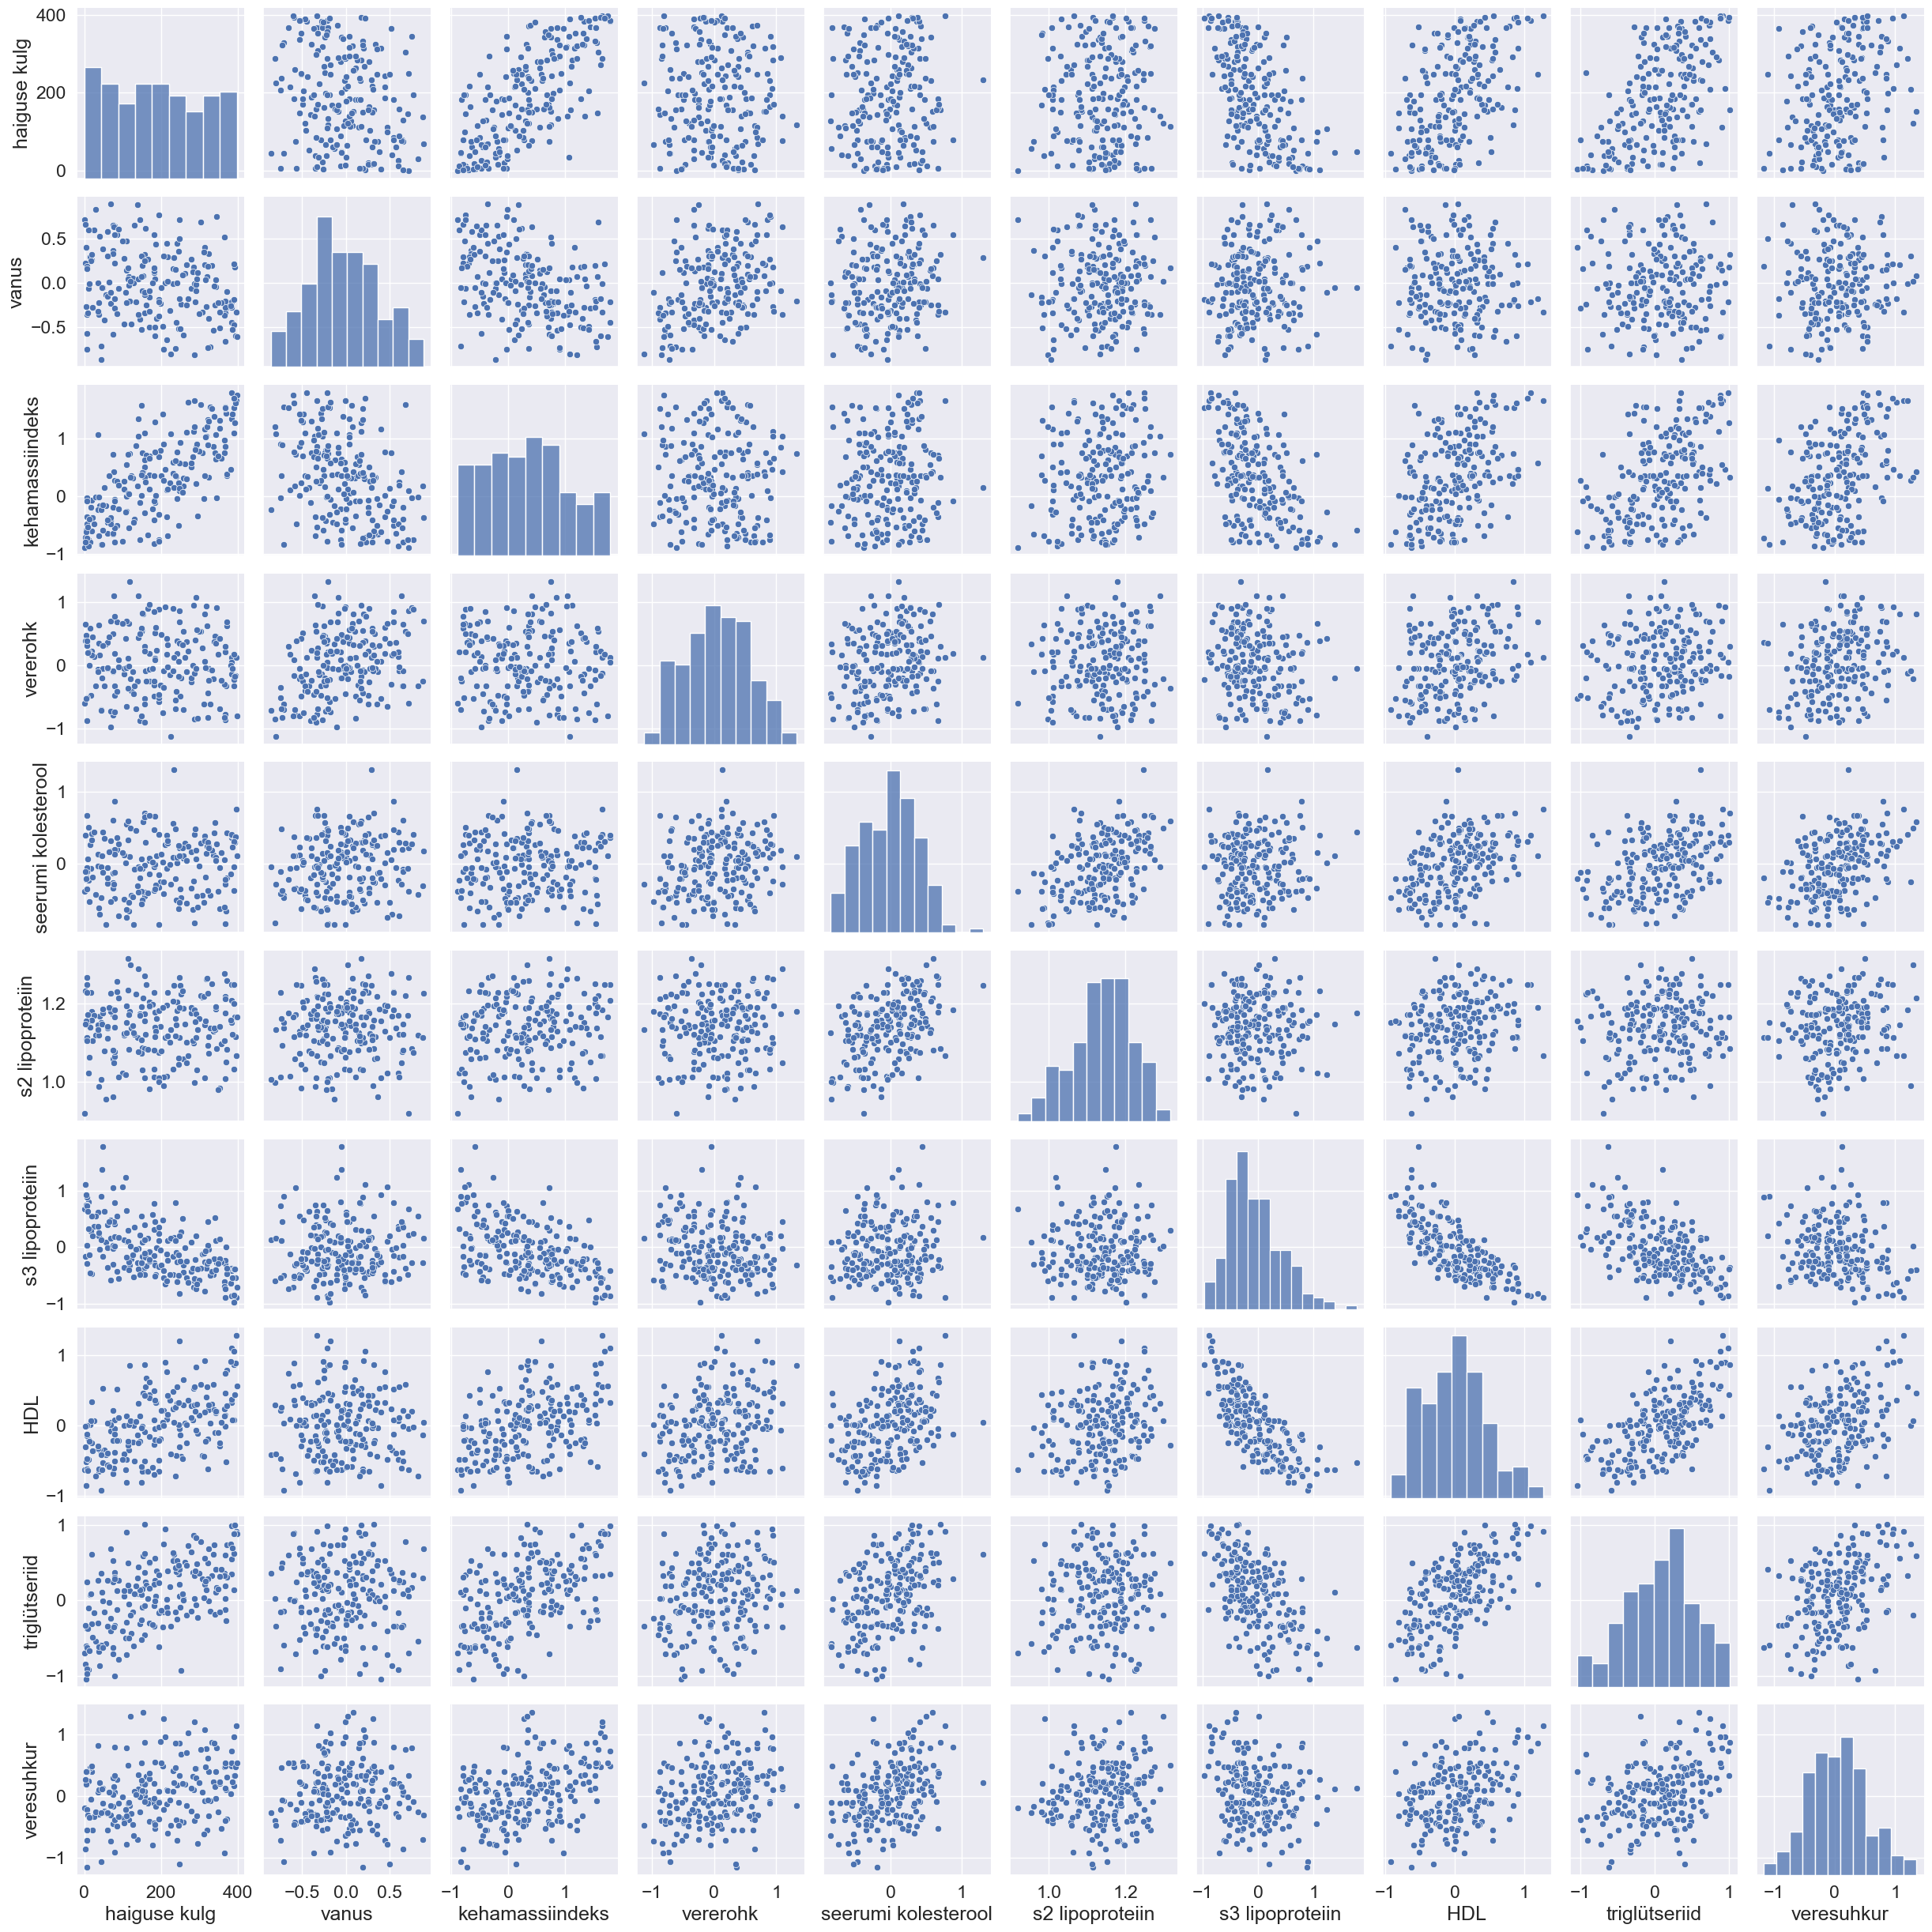

In [40]:
# Atribuutide hajuvusgraafikud
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(diabeet_df)
plt.show()


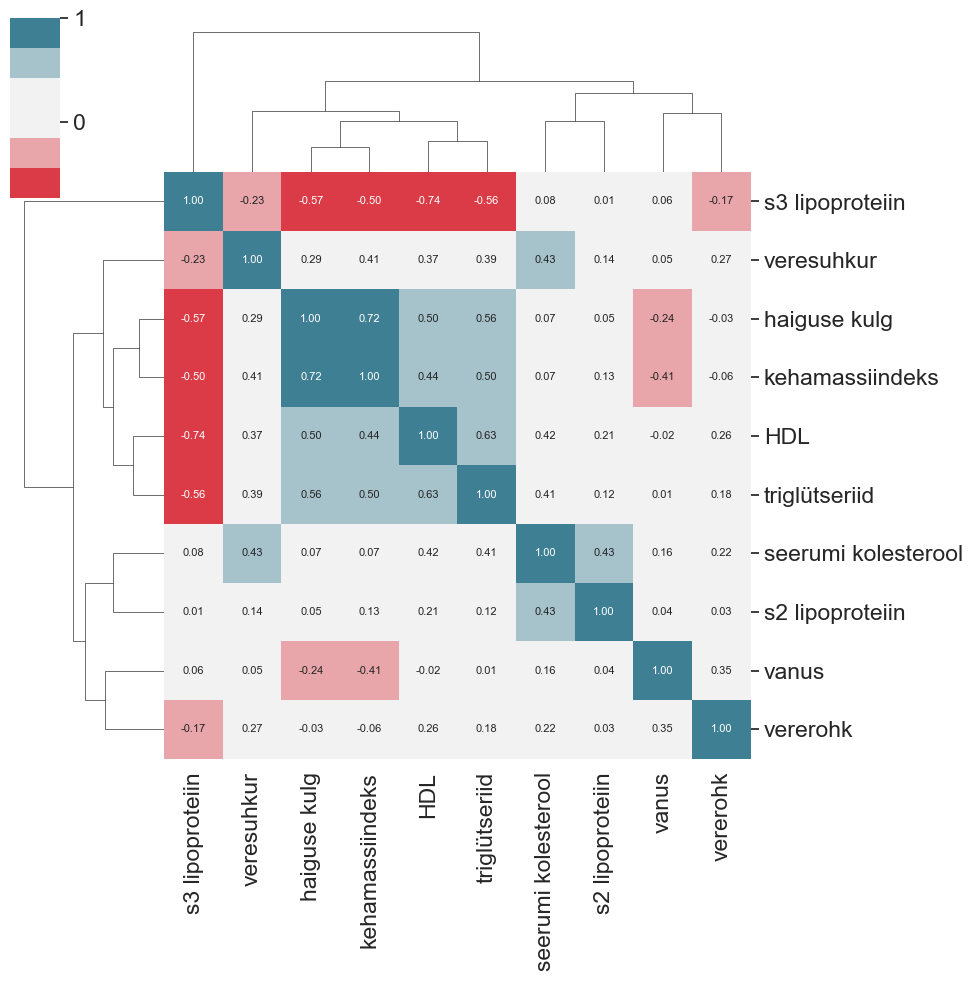

In [41]:
# Klasterdatud korr. maatriks - järjestab read ja veerud nõnda ümber, et sarnaste väärtustega ehk lähedased veerud on lähestikku.
cm = np.corrcoef(diabeet_df.T)
sns.set(font_scale=1.5)
km = sns.clustermap(cm, cbar=True, annot=True,fmt='.2f',
                    annot_kws={'size': 8}, yticklabels=diabeet_df.columns,
                    xticklabels=diabeet_df.columns, 
                    cmap=sns.diverging_palette(10, 220, sep=80))
plt.show()

In [42]:
# # Klasterdatud korr. maatriks - järjestab read ja veerud nõnda ümber, et sarnaste väärtustega ehk lähedased veerud on lähestikku.
# cm = np.corrcoef((diabeet_df).T)
# sns.set(font_scale=1.5)
# hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f',
#                  annot_kws={'size': 6}, yticklabels=diabeet_df.columns,
#                  xticklabels=diabeet_df.columns, 
#                  cmap=sns.diverging_palette(10, 220, sep=20),
#                  center=0.0)

In [43]:
# Eemaldan ennustatava veeru
haiguse_kulg = diabeet_df.pop('haiguse kulg')

Kirjeldav andmeanalüüs: PCA

In [44]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

diabeet_df_std = StandardScaler().fit_transform(diabeet_df)
pca = PCA(n_components=0.8) 
pca.fit(diabeet_df_std)

print("80% variatsioonist seletab", pca.components_.shape[0], "komponenti")
print(f'Peakomponentide omaväärtused: {pca.explained_variance_ratio_}') # Kui palju iga peakomponent seletab andmete hajuvust/varieeruvust

comp_frame = pd.DataFrame(pca.components_, columns=diabeet_df.columns).T 
comp_frame
# Interpretatsioon:
# 0: kehamassiindeks, s3 lipoproteiin, HDL, triglutseriidid, veresuhkur
# 1: vanus, vererohk, seerumi kolesterool 

80% variatsioonist seletab 5 komponenti
Peakomponentide omaväärtused: [0.3592202  0.19290372 0.14118557 0.09178907 0.07111856]


,0,1,2,3,4
vanus,-0.020134,-0.559314,-0.366577,0.186022,-0.210009
kehamassiindeks,0.366732,0.401940,0.159217,-0.217406,0.198054
vererohk,0.182530,-0.412038,-0.423844,-0.206924,0.577129
seerumi kolesterool,0.287305,-0.437388,0.396986,-0.049972,-0.360551
s2 lipoproteiin,0.168063,-0.249469,0.573404,0.464387,0.494377
s3 lipoproteiin,-0.395938,-0.279330,0.381757,-0.318111,-0.110191
HDL,0.479825,0.023257,-0.119523,0.298647,-0.052366
triglütseriid,0.455703,0.034528,-0.059398,0.065851,-0.437490
veresuhkur,0.355431,-0.150118,0.103367,-0.680029,0.053907


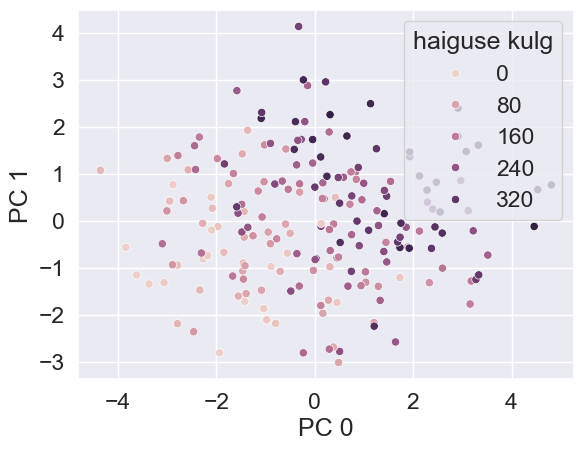

In [45]:
# Kuva objektid kahte oluliseimat komponenti pidi
import matplotlib.pyplot as plt
diabeet_df_pca = pca.transform(diabeet_df_std)

sns.scatterplot(x=diabeet_df_pca[:, 0],
                y=diabeet_df_pca[:, 1], 
                hue=haiguse_kulg)
plt.xlabel('PC 0')
plt.ylabel('PC 1')
plt.show()

## Lineaarne regressioon

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline


X = diabeet_df
y = haiguse_kulg


# Jagan andmestiku test- ja treeningandmeteks

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 
slr = Pipeline([('s', StandardScaler()), 
                ('lr', LinearRegression())])

# slr = LinearRegression()

# Treenime mudeli
slr.fit(X_train, y_train)

# Atribuutide olulisus mudelis
for col_name, x_i in zip(X.columns, slr.named_steps['lr'].coef_):
    print(col_name + "\t", round(x_i, 4))


vanus	 4.3365
kehamassiindeks	 64.8131
vererohk	 -6.4682
seerumi kolesterool	 -6.9711
s2 lipoproteiin	 -2.5819
s3 lipoproteiin	 -15.7209
HDL	 16.1649
triglütseriid	 17.5278
veresuhkur	 -2.306


Mudeli interpretatsioon: 

* kõrge kehamassiindeks, HDL ja triglütseriidide tase suurendavad diabeedi raskuse kulgu,

* kõrge s3 lipoproteiini tase vähendab haiguse raskuse kulgu.



Treenitud mudeli headuse hindamine.

In [47]:
# Determinatsioonikordaja R2 lr mudeli hindamiseks - mõõdab kui suurt osa ennustatava muutuja varieeruvusest regressioonimudel seletab (see on 1, kui mudel ennustab 
# alati õigesti, on 0, kui ennustab alati kesmist ning negatiivne, kui ennustab veel kehvemini)
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=slr,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print('Ristkontrollil (CV) keskmine R2 täpsus: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores)) 
# k-kordne ristkontroll jagab andmestiku k võrdseks juhuvalimiks, kus k-1 juhuvalimit kasutatakse treeninguks ja viimast juhuvalimit testimiseks. 
# Seda protseduri korratakse k korda, kuni testitud on kõiki juhuvalimeid. Koguhinnang E (täpsus vms) on keskmine hinnang üle k hinnangu
print('Keskmine R2 täpsus treeningandmetel: %.3f' % slr.score(X_train, y_train))
print('Keskmine R2 täpsus testandmetel: %.3f' % slr.score(X_test, y_test))


Ristkontrollil (CV) keskmine R2 täpsus: 0.432 +/- 0.205
Keskmine R2 täpsus treeningandmetel: 0.602
Keskmine R2 täpsus testandmetel: 0.618


## Polünomiaalne regressioon


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

plr = Pipeline(steps = [('s', StandardScaler()),
                        ('pf', PolynomialFeatures(degree=2)),
                        ('lr', LinearRegression())])

plr.fit(X_train, y_train)
scores = cross_val_score(estimator=plr,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print('CV keskmine R2 täpsus: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))
print('Keskmine R2 täpsus treeningandmetel: %.3f' % plr.score(X_train, y_train))
print('Keskmine R2 täpsus testandmetel: %.3f' % plr.score(X_test, y_test))

# Mõlema mudeli täpsus testandmetel on võrreldav, aga ristkontroll (CV) näitab, et polünomiaalse regressiooni tulemus sõltub tugevalt 
# treening/testandmete jaotusest (suur varieeruvus täpsushinnangus)

CV keskmine R2 täpsus: 0.096 +/- 0.424
Keskmine R2 täpsus treeningandmetel: 0.754
Keskmine R2 täpsus testandmetel: 0.090


Lineaarregressiooni mudeli täpsus testandmetel on palju parem, kui polünomiaalregresiooonil.

Ristkontroll (CV) näitab, et polünomiaalse regressiooni tulemus sõltub suuresti treening/testandmete jaotusest (suur varieeruvus täpsushinnangus).

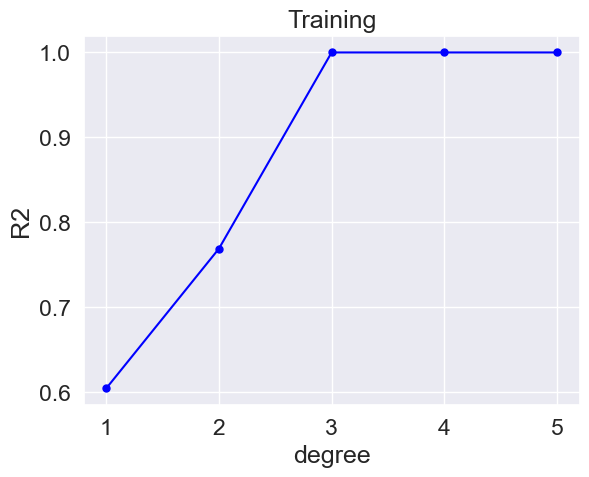

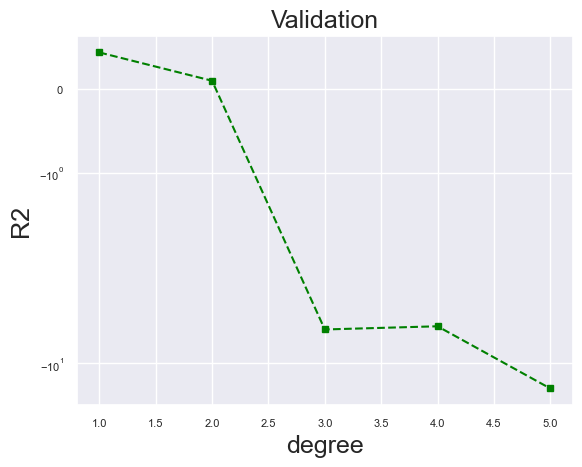

In [49]:
# Polünomiaalregressiooni astme validatsioonikõver

from sklearn.model_selection import validation_curve

param_range = range(1, 6)
train_scores, test_scores = validation_curve(
                estimator=plr, 
                X=X_train, 
                y=y_train, 
                param_name='pf__degree', #formaat: KonveieriKomponendiNimi__ParameetriNimi
                param_range=param_range,
                cv=10)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)


plt.plot(param_range, train_mean, 
         color='blue', marker='o', 
         markersize=5)
plt.xlabel('degree')
plt.ylabel('R2')
plt.title("Training")
plt.show()

plt.plot(param_range, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5)
plt.xlabel('degree')
plt.ylabel('R2')
plt.title("Validation")
plt.yscale('symlog')
plt.tick_params(axis='both', labelsize=8)
plt.show()


Alates kolmest suuremate degree väärtuste korral on naiivne R2 skoor treeningandmetel väga hea, aga kontrollil testandmetega äärmuslikult negatiivne.

## Otsustuspuu ja -metsa regressioon 


In [50]:
# Otsustuspuu ennustuseks objektile on vastavas otsustuspuu lehes olevate treeningandmete keskväärtus. Juhuslikus metsas keskmistatakse 
# ennustused veelkord üle metsa puude.
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# DecisionTreeRegressor

puu = Pipeline([('sc', StandardScaler()), 
                ('puu', DecisionTreeRegressor(max_depth=3))])
# puu = DecisionTreeRegressor(max_depth=3)

puu.fit(X_train, y_train)

scores = cross_val_score(estimator=puu,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print('Puu CV keskmine R2 täpsus: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))

print('Puu täpsus R2 treeningandmetel: %.3f' % puu.score(X_train, y_train))
print('Puu täpsus R2 testandmetel: %.3f \n' % puu.score(X_test, y_test))


# RandomForestRegressor

mets = Pipeline([('sc', StandardScaler()), 
                ('mets', RandomForestRegressor(n_estimators=100, criterion='friedman_mse'))])
# mets = RandomForestRegressor(n_estimators=100, criterion='friedman_mse')

mets.fit(X_train, y_train)

scores = cross_val_score(estimator=mets,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print('Metsa CV keskmine R2 täpsus: %.3f' % np.mean(scores), "+/- %.3f" % np.std(scores))

print('Metsa täpsus R2 treeningandmetel: %.3f' % mets.score(X_train, y_train))
print('Metsa täpsus R2 testandmetel: %.3f' % mets.score(X_test, y_test))


Puu CV keskmine R2 täpsus: 0.152 +/- 0.308
Puu täpsus R2 treeningandmetel: 0.656
Puu täpsus R2 testandmetel: 0.276 

Metsa CV keskmine R2 täpsus: 0.372 +/- 0.215
Metsa täpsus R2 treeningandmetel: 0.934
Metsa täpsus R2 testandmetel: 0.408


Otsustusmets on täpsem. 

Vaatame, mis atribuudid on ennustamisel oluliseimad.

In [51]:
print("Juhusliku metsa attr tähtsused:")
fi = mets.named_steps["mets"].feature_importances_
for i, f in sorted(zip(fi, diabeet_df.columns), reverse=True):
    print(f, i)

Juhusliku metsa attr tähtsused:
kehamassiindeks 0.5480895699222403
s3 lipoproteiin 0.09738474938209216
HDL 0.08923604884371086
vererohk 0.05309850166055513
triglütseriid 0.05213421536776093
veresuhkur 0.0489194510177954
seerumi kolesterool 0.04504579091471944
s2 lipoproteiin 0.036264863680275525
vanus 0.02982680921085027


Ennustamisel on otsustusmetsas kõige olulisem kehamassiindeks, seejärel s3 lipopreoteiin ja HDL.

## MUDELITE VÕRDLUS

### 1. Lineaarregressioon: 

CV keskmine R2 täpsus: 0.432 +/- 0.205

Keskmine R2 täpsus treeningandmetel: 0.602

Keskmine R2 täpsus testandmetel: 0.618

### 2. Polünomiaalregressioon

CV keskmine R2 täpsus: 0.096 +/- 0.424

Keskmine R2 täpsus treeningandmetel: 0.754

Keskmine R2 täpsus testandmetel: 0.090

### 3. Otsustuspuu

Puu CV keskmine R2 täpsus: 0.152 +/- 0.308

Puu täpsus R2 treeningandmetel: 0.656

Puu täpsus R2 testandmetel: 0.276 

### 4. Otsustusmets

Metsa CV keskmine R2 täpsus: 0.368 +/- 0.189

Metsa täpsus R2 treeningandmetel: 0.928

Metsa täpsus R2 testandmetel: 0.458

##### Näeme, et lineaarse regressiooni mudelil on kõrgeim R2 skoor. Samas ristkontroll (CV) näitab, et täpsushinnang varieerub üsna palju (tulemus sõltub treening/testandmete jaotusest).

##### Otsustusmetsal on järgmiselt parim R2 skoor. Selle mudeli varieeruvus täpsushinnangus on veidi väiksem kui eelmise mudeliga.

Otsustuspuu ja polünomiaalse mudeli täpsused on madalad ning varieeruvus suur.
